# 083: KmerSeek-fails / FoldSeek-wins — Structural Characterization

In the head-to-head benchmark (228 queries where both methods have Bonferroni-significant hits,
using `hp_thomas_dill k=26`), 26 queries have:
- **KM_FAM = 0** — KmerSeek finds family members for zero fraction of queries before the first false positive
- **FS_FAM ≥ 0.9** — FoldSeek finds ≥ 90% of family members

Goal: are these a coherent structural class (clean limitation paragraph) or random noise?

**Depends on:** 076 notebook (same data paths, `hp_thomas_dill k=26`)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import gc
import sys
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

sys.path.append(str(Path.cwd()))
from scope_kmerseek_utils import (
    EVAL_USECOLS, TEA_DIR, SCOPE_CLASS_DESCRIPTIONS,
    load_baselines, add_composite_scores_scope, recompute_bonferroni,
    eval_tsv_to_rocx,
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 120

SWEEP_DIR      = Path.home() / 'data/scope/results-hp-alphabet-sweep'
SCOPE_DOM_PATH = Path.home() / 'data/scope/results-scope-pvalue-benchmark/scope_domains.tsv'
FASTA_PATH     = Path.home() / 'data/scope/astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa'
FIG_PREFIX     = '../figures/083'
Path('../figures').mkdir(exist_ok=True)

BEST_LABEL     = 'hp_thomas_dill'
BEST_K         = 26
BONF_THRESHOLD = 0.05
FS_WIN_THRESH  = 0.9    # FoldSeek must find >=90% of family before first FP

def eval_path(label: str, k: int) -> Path:
    gz = SWEEP_DIR / f'scope_eval.{label}.k{k}.tsv.gz'
    return gz if gz.exists() else SWEEP_DIR / f'scope_eval.{label}.k{k}.tsv'

print(f'Best: {BEST_LABEL} k={BEST_K}  Bonf<{BONF_THRESHOLD}  FS_win_thresh={FS_WIN_THRESH}')

Best: hp_thomas_dill k=26  Bonf<0.05  FS_win_thresh=0.9


## 1. Build head-to-head set and identify FS-wins

In [3]:
foldseek, _ = load_baselines(TEA_DIR)
ref_queries = set(foldseek['NAME'].to_list())

# Load KmerSeek eval, filter Bonferroni-significant
ev = pl.read_csv(eval_path(BEST_LABEL, BEST_K), separator='\t')
ev = add_composite_scores_scope(ev)
ev = recompute_bonferroni(ev)
ev_filt = ev.filter(pl.col('bonferroni_correct') < BONF_THRESHOLD)
km_rocx_all = eval_tsv_to_rocx(ev_filt, score_col='jaccard', ascending=False, exclude_gray_zone=True)
# Keep raw eval for failure-mode analysis below
ev_for_analysis = ev_filt.clone()
del ev; gc.collect()

# Remove class e (multidomain) — FoldSeek never benchmarked those
_e = set(foldseek.filter(pl.col('SCOP').str.slice(0, 1) == 'e')['NAME'].to_list())
foldseek    = foldseek.filter(   pl.col('SCOP').str.slice(0, 1) != 'e')
km_rocx_all = km_rocx_all.filter(pl.col('SCOP').str.slice(0, 1) != 'e')
ref_queries = ref_queries - _e
km_rocx_r   = km_rocx_all.filter(pl.col('NAME').is_in(ref_queries))

# Per-query FAM sensitivity dicts
km_fam_d    = dict(zip(km_rocx_r['NAME'].to_list(), km_rocx_r['FAM'].to_list()))
fs_fam_d    = dict(zip(foldseek['NAME'].to_list(),  foldseek['FAM'].to_list()))
fs_famcnt_d = dict(zip(foldseek['NAME'].to_list(),  foldseek['FAMCNT'].to_list()))
fs_scop_d   = dict(zip(foldseek['NAME'].to_list(),  foldseek['SCOP'].to_list()))

shared = sorted(set(km_fam_d) & set(fs_fam_d))
km_arr = np.array([km_fam_d[q] for q in shared])
fs_arr = np.array([fs_fam_d[q] for q in shared])
diff   = km_arr - fs_arr

print(f'H2H shared queries: {len(shared)}')
print(f'  KM > FS: {(diff > 0).sum()}')
print(f'  Tie:     {(diff == 0).sum()}')
print(f'  FS > KM: {(diff < 0).sum()}')
print()

# ── The 26: KM completely fails (FAM=0), FS strongly wins (FAM>=0.9) ──────
fs_wins_26_mask = (km_arr == 0) & (fs_arr >= FS_WIN_THRESH)
fs_wins_26 = [shared[i] for i in range(len(shared)) if fs_wins_26_mask[i]]
print(f'KM_FAM=0 AND FS_FAM>={FS_WIN_THRESH}: {len(fs_wins_26)} queries')
print(f'  (these are the "26 KM-fails / FS-wins" for characterization)')

# Also track the full FS-wins (any diff<0) for context
fs_wins_all = [shared[i] for i in range(len(shared)) if diff[i] < 0]
print(f'\nAll FS-wins (FS_FAM > KM_FAM): {len(fs_wins_all)}')
print(f'  Of which KM_FAM=0: {sum(1 for i in range(len(shared)) if diff[i] < 0 and km_arr[i] == 0)}')

H2H shared queries: 228
  KM > FS: 110
  Tie:     77
  FS > KM: 41

KM_FAM=0 AND FS_FAM>=0.9: 26 queries
  (these are the "26 KM-fails / FS-wins" for characterization)

All FS-wins (FS_FAM > KM_FAM): 41
  Of which KM_FAM=0: 40


## 2. Join with SCOPe annotation

In [4]:
scope_domains = pl.read_csv(SCOPE_DOM_PATH, separator='\t')

# Build annotation table for the 26
fails_df = pl.DataFrame({'domain_id': fs_wins_26}).join(
    scope_domains, on='domain_id', how='left'
).with_columns([
    pl.Series('fs_fam',    [fs_fam_d[q]    for q in fs_wins_26]),
    pl.Series('km_fam',    [km_fam_d[q]    for q in fs_wins_26]),
    pl.Series('fs_famcnt', [fs_famcnt_d[q] for q in fs_wins_26]),
]).sort('scop_class')

print(f'Annotated: {fails_df.height} queries')
print(fails_df.select(['domain_id', 'scop_id', 'scop_class', 'scop_superfamily', 'scop_family', 'fs_fam', 'fs_famcnt', 'protein_name']))

Annotated: 26 queries
shape: (26, 8)
┌───────────┬────────────┬────────────┬─────────────┬────────────┬────────┬───────────┬────────────┐
│ domain_id ┆ scop_id    ┆ scop_class ┆ scop_superf ┆ scop_famil ┆ fs_fam ┆ fs_famcnt ┆ protein_na │
│ ---       ┆ ---        ┆ ---        ┆ amily       ┆ y          ┆ ---    ┆ ---       ┆ me         │
│ str       ┆ str        ┆ str        ┆ ---         ┆ ---        ┆ f64    ┆ i64       ┆ ---        │
│           ┆            ┆            ┆ str         ┆ str        ┆        ┆           ┆ str        │
╞═══════════╪════════════╪════════════╪═════════════╪════════════╪════════╪═══════════╪════════════╡
│ d2wzka1   ┆ a.118.17.0 ┆ a          ┆ a.118.17    ┆ a.118.17.0 ┆ 1.0    ┆ 3         ┆ automated  │
│           ┆            ┆            ┆             ┆            ┆        ┆           ┆ matches    │
│ d6i2mb_   ┆ a.118.17.0 ┆ a          ┆ a.118.17    ┆ a.118.17.0 ┆ 1.0    ┆ 3         ┆ automated  │
│           ┆            ┆            ┆             ┆ 

## 3. SCOP class and structural-class distribution

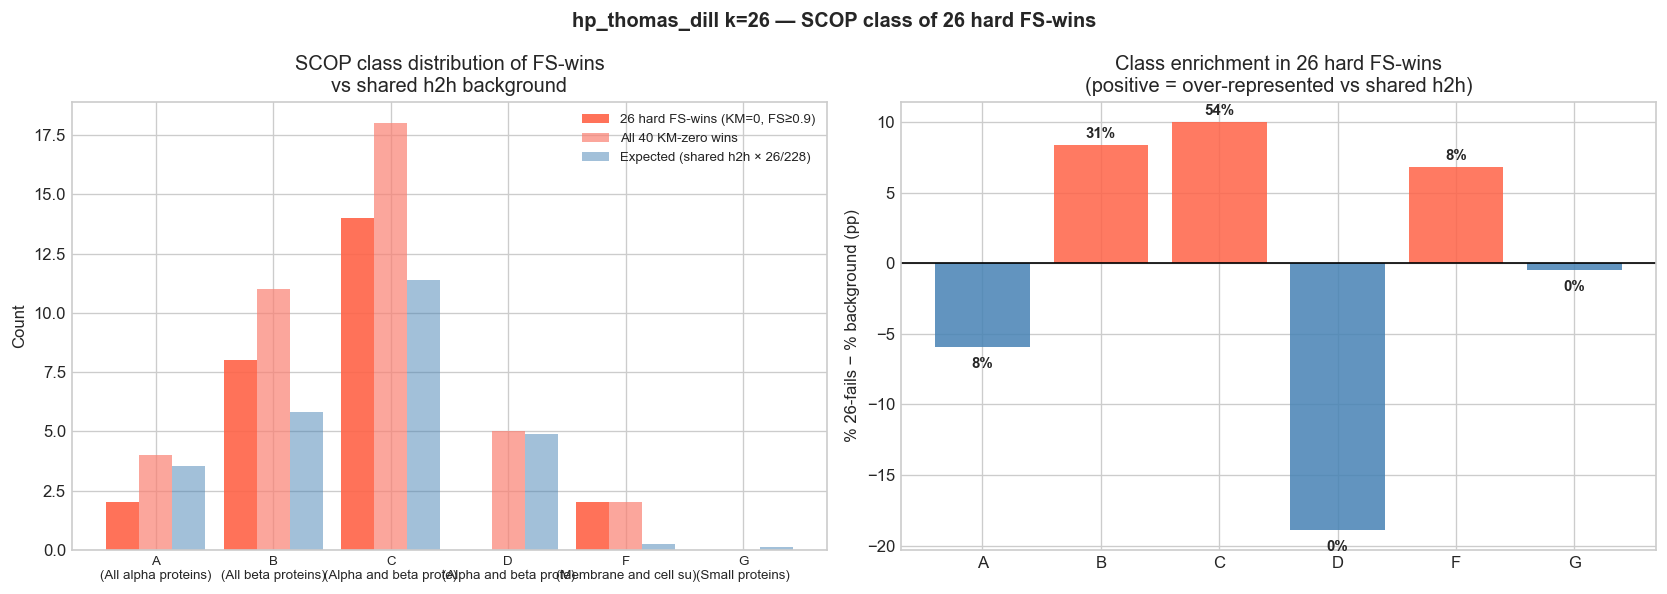


Class breakdown of 26 hard FS-wins:
  A: 2/26 (8%)  background: 31/228 (14%)  [All alpha proteins]
  B: 8/26 (31%)  background: 51/228 (22%)  [All beta proteins]
  C: 14/26 (54%)  background: 100/228 (44%)  [Alpha and beta proteins (a/b) — alternat]
  D: 0/26 (0%)  background: 43/228 (19%)  [Alpha and beta proteins (a+b) — segregat]
  F: 2/26 (8%)  background: 2/228 (1%)  [Membrane and cell surface proteins]
  G: 0/26 (0%)  background: 1/228 (0%)  [Small proteins]


In [5]:
# ── Build comparison baselines ────────────────────────────────────────────
# All 228 h2h shared queries (context)
shared_scop = [fs_scop_d[q][0] for q in shared]  # first letter = class
shared_cls_cnt = Counter(shared_scop)

# The 26 fails
fails26_scop = [fs_scop_d[q][0] for q in fs_wins_26]
fails26_cls_cnt = Counter(fails26_scop)

# All 40 KM_FAM=0 FS-wins (broader view)
km_zero_wins = [shared[i] for i in range(len(shared)) if km_arr[i] == 0 and fs_arr[i] > 0]
km_zero_cls  = Counter([fs_scop_d[q][0] for q in km_zero_wins])

classes = sorted(set(list(shared_cls_cnt) + list(fails26_cls_cnt)) - {'e'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw counts
ax = axes[0]
x = np.arange(len(classes))
w = 0.28
n_shared = len(shared)
n_26     = len(fs_wins_26)
n_40     = len(km_zero_wins)
bars_26 = ax.bar(x - w,   [fails26_cls_cnt.get(c, 0) for c in classes], w, 
                 color='tomato', alpha=0.9, label=f'26 hard FS-wins (KM=0, FS≥{FS_WIN_THRESH})')
bars_40 = ax.bar(x,       [km_zero_cls.get(c, 0)    for c in classes], w,
                 color='salmon', alpha=0.7, label=f'All 40 KM-zero wins')
bars_bg = ax.bar(x + w,   [shared_cls_cnt.get(c, 0) / n_shared * n_26 for c in classes], w,
                 color='steelblue', alpha=0.5, label=f'Expected (shared h2h × 26/{n_shared})')
ax.set_xticks(x)
ax.set_xticklabels([f'{c.upper()}\n({SCOPE_CLASS_DESCRIPTIONS.get(c, c)[:20]})' 
                    for c in classes], fontsize=8)
ax.set_ylabel('Count')
ax.set_title(f'SCOP class distribution of FS-wins\nvs shared h2h background')
ax.legend(fontsize=8)

# Right: fraction of 26 vs background fraction
ax = axes[1]
pct_26 = np.array([100 * fails26_cls_cnt.get(c, 0) / n_26 for c in classes])
pct_bg = np.array([100 * shared_cls_cnt.get(c, 0) / n_shared for c in classes])
enrichment = pct_26 - pct_bg
colors = ['tomato' if e > 0 else 'steelblue' for e in enrichment]
ax.bar(x, enrichment, color=colors, alpha=0.85)
ax.axhline(0, color='black', lw=1)
ax.set_xticks(x)
ax.set_xticklabels([c.upper() for c in classes], fontsize=10)
ax.set_ylabel('% 26-fails − % background (pp)')
ax.set_title(f'Class enrichment in 26 hard FS-wins\n(positive = over-represented vs shared h2h)')
for xi, (e, pct) in enumerate(zip(enrichment, pct_26)):
    ax.text(xi, e + (0.5 if e >= 0 else -1.5), f'{pct:.0f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle(f'{BEST_LABEL} k={BEST_K} — SCOP class of 26 hard FS-wins', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_PREFIX}_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClass breakdown of 26 hard FS-wins:')
for c in classes:
    n_c   = fails26_cls_cnt.get(c, 0)
    bg_c  = shared_cls_cnt.get(c, 0)
    desc  = SCOPE_CLASS_DESCRIPTIONS.get(c, c)
    print(f'  {c.upper()}: {n_c}/{n_26} ({100*n_c/n_26:.0f}%)  '
          f'background: {bg_c}/{n_shared} ({100*bg_c/n_shared:.0f}%)  '
          f'[{desc[:40]}]')

## 4. Family size: how big are the families that FoldSeek finds but KmerSeek misses?

Family sizes — 26 fails: median=8  mean=24.3
Family sizes — all h2h:  median=21  mean=40.0
Mann-Whitney (two-sided): p=0.0264


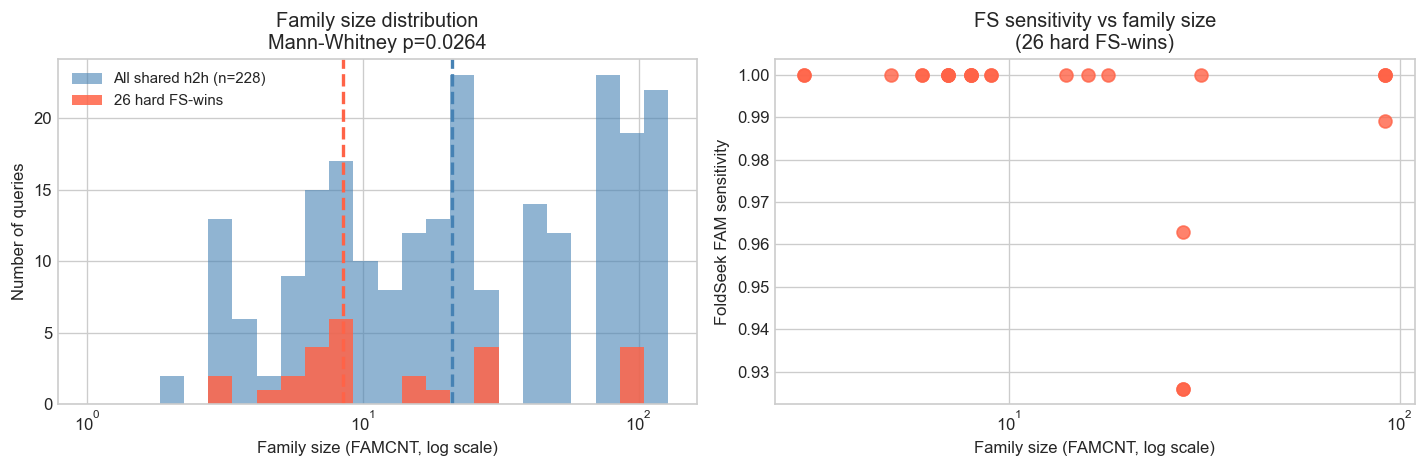

In [6]:
# Compare family sizes: 26 fails vs all 228 h2h shared
famcnt_26 = np.array([fs_famcnt_d[q] for q in fs_wins_26])
famcnt_shared = np.array([fs_famcnt_d[q] for q in shared])

from scipy.stats import mannwhitneyu
stat, pval = mannwhitneyu(famcnt_26, famcnt_shared, alternative='two-sided')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
bins = np.logspace(np.log10(1), np.log10(max(famcnt_shared.max(), famcnt_26.max()) + 1), 25)
ax.hist(famcnt_shared, bins=bins, color='steelblue', alpha=0.6, label=f'All shared h2h (n={len(shared)})')
ax.hist(famcnt_26,     bins=bins, color='tomato',    alpha=0.85, label=f'26 hard FS-wins')
ax.set_xscale('log')
ax.set_xlabel('Family size (FAMCNT, log scale)')
ax.set_ylabel('Number of queries')
ax.set_title(f'Family size distribution\nMann-Whitney p={pval:.3g}')
ax.legend(fontsize=9)
ax.axvline(np.median(famcnt_26),     color='tomato',    lw=2, ls='--', label=f'median={np.median(famcnt_26):.0f}')
ax.axvline(np.median(famcnt_shared), color='steelblue', lw=2, ls='--')

ax = axes[1]
ax.scatter(famcnt_26, [fs_fam_d[q] for q in fs_wins_26], color='tomato', alpha=0.8, s=60)
ax.set_xscale('log')
ax.set_xlabel('Family size (FAMCNT, log scale)')
ax.set_ylabel('FoldSeek FAM sensitivity')
ax.set_title('FS sensitivity vs family size\n(26 hard FS-wins)')

print(f'Family sizes — 26 fails: median={np.median(famcnt_26):.0f}  mean={famcnt_26.mean():.1f}')
print(f'Family sizes — all h2h:  median={np.median(famcnt_shared):.0f}  mean={famcnt_shared.mean():.1f}')
print(f'Mann-Whitney (two-sided): p={pval:.4g}')

plt.tight_layout()
plt.savefig(f'{FIG_PREFIX}_famsize.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Sequence length and HP composition

In [7]:
# ── Parse FASTA for lengths and HP ratios ────────────────────────────────
# HP alphabet: H = hydrophobic (ACFILMVWY), P = polar (everything else)
# SCOPe FASTA uses lowercase — must upper() before checking
HP_HYDROPHOBIC = set('ACFILMVWY')

seq_info = {}  # domain_id -> {'len': int, 'hp_ratio': float}
query_set = set(fs_wins_26) | set(shared)  # only parse what we need

current_id = None
current_seq = []
with open(FASTA_PATH) as fh:
    for line in fh:
        line = line.rstrip()
        if line.startswith('>'):
            if current_id and current_id in query_set:
                seq = ''.join(current_seq).upper()
                hp = sum(1 for aa in seq if aa in HP_HYDROPHOBIC)
                seq_info[current_id] = {'len': len(seq), 'hp_ratio': hp / max(len(seq), 1)}
            # SCOPe FASTA header: >d1abc__ space ...
            current_id = line[1:].split()[0]
            current_seq = []
        else:
            current_seq.append(line)
    # last record
    if current_id and current_id in query_set:
        seq = ''.join(current_seq).upper()
        hp  = sum(1 for aa in seq if aa in HP_HYDROPHOBIC)
        seq_info[current_id] = {'len': len(seq), 'hp_ratio': hp / max(len(seq), 1)}

n_found = sum(1 for q in fs_wins_26 if q in seq_info)
print(f'Parsed FASTA: {n_found}/{len(fs_wins_26)} of the 26 fails found')
print(f'Total parsed: {len(seq_info)}')
# Sanity check
sample_id = list(seq_info.keys())[0]
print(f'Sanity — {sample_id}: len={seq_info[sample_id]["len"]}  hp_ratio={seq_info[sample_id]["hp_ratio"]:.3f}')

Parsed FASTA: 26/26 of the 26 fails found
Total parsed: 228
Sanity — d3d1kb_: len=146  hp_ratio=0.466


Length — 26 fails:  median=351  mean=369
Length — all h2h:   median=147  mean=208
Length Mann-Whitney: p=1.176e-07

HP ratio — 26 fails: median=0.431  mean=0.424
HP ratio — all h2h:  median=0.422  mean=0.420
HP ratio Mann-Whitney: p=0.5307


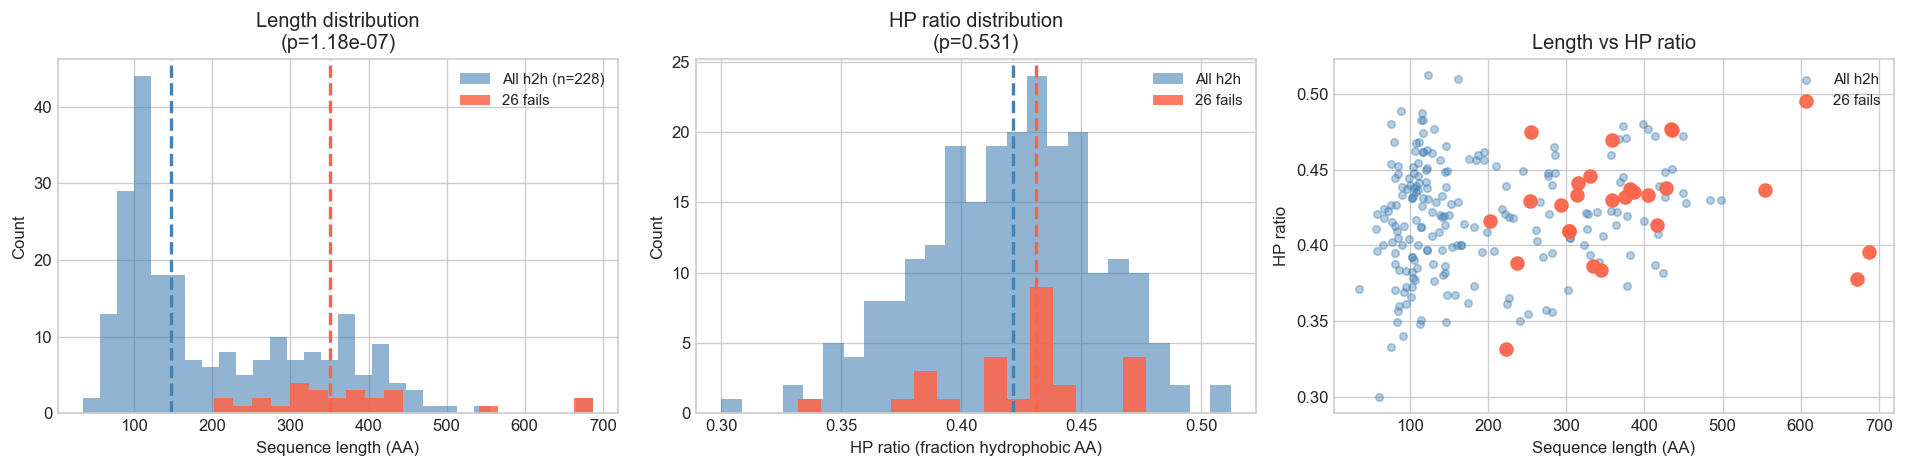

In [8]:
lens_26     = np.array([seq_info[q]['len']      for q in fs_wins_26 if q in seq_info])
hp_26       = np.array([seq_info[q]['hp_ratio'] for q in fs_wins_26 if q in seq_info])
lens_shared = np.array([seq_info[q]['len']      for q in shared     if q in seq_info])
hp_shared   = np.array([seq_info[q]['hp_ratio'] for q in shared     if q in seq_info])

stat_len, pval_len = mannwhitneyu(lens_26, lens_shared, alternative='two-sided')
stat_hp,  pval_hp  = mannwhitneyu(hp_26,   hp_shared,  alternative='two-sided')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.hist(lens_shared, bins=30, color='steelblue', alpha=0.6, label=f'All h2h (n={len(lens_shared)})')
ax.hist(lens_26,     bins=20, color='tomato',    alpha=0.85, label=f'26 fails')
ax.axvline(np.median(lens_26),     color='tomato',    lw=2, ls='--')
ax.axvline(np.median(lens_shared), color='steelblue', lw=2, ls='--')
ax.set_xlabel('Sequence length (AA)')
ax.set_ylabel('Count')
ax.set_title(f'Length distribution\n(p={pval_len:.3g})')
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(hp_shared, bins=25, color='steelblue', alpha=0.6, label=f'All h2h')
ax.hist(hp_26,     bins=15, color='tomato',    alpha=0.85, label=f'26 fails')
ax.axvline(np.median(hp_26),     color='tomato',    lw=2, ls='--')
ax.axvline(np.median(hp_shared), color='steelblue', lw=2, ls='--')
ax.set_xlabel('HP ratio (fraction hydrophobic AA)')
ax.set_ylabel('Count')
ax.set_title(f'HP ratio distribution\n(p={pval_hp:.3g})')
ax.legend(fontsize=9)

ax = axes[2]
ax.scatter(lens_shared, hp_shared, color='steelblue', alpha=0.4, s=20, label=f'All h2h')
ax.scatter(lens_26,     hp_26,     color='tomato',    alpha=0.9, s=60, label=f'26 fails')
ax.set_xlabel('Sequence length (AA)')
ax.set_ylabel('HP ratio')
ax.set_title('Length vs HP ratio')
ax.legend(fontsize=9)

print(f'Length — 26 fails:  median={np.median(lens_26):.0f}  mean={lens_26.mean():.0f}')
print(f'Length — all h2h:   median={np.median(lens_shared):.0f}  mean={lens_shared.mean():.0f}')
print(f'Length Mann-Whitney: p={pval_len:.4g}')
print()
print(f'HP ratio — 26 fails: median={np.median(hp_26):.3f}  mean={hp_26.mean():.3f}')
print(f'HP ratio — all h2h:  median={np.median(hp_shared):.3f}  mean={hp_shared.mean():.3f}')
print(f'HP ratio Mann-Whitney: p={pval_hp:.4g}')

plt.tight_layout()
plt.savefig(f'{FIG_PREFIX}_seq_props.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. KmerSeek failure mode: what does KmerSeek actually find for these proteins?

In [9]:
# For each of the 26 fails: what are KmerSeek's top hits?
# ev_for_analysis = Bonf-filtered eval rows
ev_fa = ev_for_analysis.with_columns([
    pl.col('query_domain').str.split(' ').list.first().alias('_qid'),
    pl.col('target_domain').str.split(' ').list.first().alias('_tid'),
])

fails_ev = ev_fa.filter(pl.col('_qid').is_in(fs_wins_26))
print(f'KmerSeek Bonf-sig rows for the 26 fails: {fails_ev.height}')

# For each fail query: top-5 KmerSeek hits by Jaccard
top_hits = (
    fails_ev
    .sort('jaccard', descending=True)
    .group_by('_qid')
    .agg([
        pl.col('_tid').head(5).alias('top5_targets'),
        pl.col('jaccard').head(5).alias('top5_jaccard'),
        pl.col('same_family').head(5).alias('top5_same_fam'),
        pl.col('same_superfamily').head(5).alias('top5_same_sfam'),
        pl.col('jaccard').count().alias('n_sig_hits'),
        pl.col('same_family').sum().alias('n_family_tps'),
        pl.col('same_superfamily').sum().alias('n_sfam_tps'),
    ])
)

# Join with annotation
top_hits_ann = top_hits.join(
    fails_df.select(['domain_id', 'scop_id', 'scop_class', 'scop_family', 'fs_fam', 'fs_famcnt', 'protein_name']),
    left_on='_qid', right_on='domain_id', how='left'
).sort('scop_class')

print(f'\nQueries with KmerSeek hits: {top_hits.height}')
print(f'Queries with NO KmerSeek hits (entirely missed): {len(fs_wins_26) - top_hits.height}')
print()
print('For each fail query: n_sig_hits, n_family_TPs, n_sfam_TPs (among Bonf-sig hits):')
for row in top_hits_ann.iter_rows(named=True):
    q = row['_qid']
    print(f"  {q}  class={row.get('scop_class','?')}  fam={row.get('scop_family','?')}  "
          f"n_sig={row['n_sig_hits']}  n_fam_TP={row['n_family_tps']}  n_sfam_TP={row['n_sfam_tps']}  "
          f"FS_FAM={row.get('fs_fam',0):.2f}  FAMCNT={row.get('fs_famcnt',0)}")

KmerSeek Bonf-sig rows for the 26 fails: 69

Queries with KmerSeek hits: 26
Queries with NO KmerSeek hits (entirely missed): 0

For each fail query: n_sig_hits, n_family_TPs, n_sfam_TPs (among Bonf-sig hits):
  d6i2mb_  class=a  fam=a.118.17.0  n_sig=3  n_fam_TP=1  n_sfam_TP=1  FS_FAM=1.00  FAMCNT=3
  d2wzka1  class=a  fam=a.118.17.0  n_sig=2  n_fam_TP=1  n_sfam_TP=1  FS_FAM=1.00  FAMCNT=3
  d1p22a2  class=b  fam=b.69.4.1  n_sig=2  n_fam_TP=1  n_sfam_TP=1  FS_FAM=1.00  FAMCNT=16
  d6id0e_  class=b  fam=b.69.4.0  n_sig=3  n_fam_TP=1  n_sfam_TP=1  FS_FAM=1.00  FAMCNT=8
  d4yvda_  class=b  fam=b.69.4.0  n_sig=2  n_fam_TP=1  n_sfam_TP=1  FS_FAM=1.00  FAMCNT=8
  d4leja2  class=b  fam=b.82.1.0  n_sig=2  n_fam_TP=1  n_sfam_TP=1  FS_FAM=1.00  FAMCNT=18
  d3frxa_  class=b  fam=b.69.4.0  n_sig=3  n_fam_TP=1  n_sfam_TP=1  FS_FAM=1.00  FAMCNT=8
  d7kn8a1  class=b  fam=b.69.13.0  n_sig=2  n_fam_TP=1  n_sfam_TP=1  FS_FAM=1.00  FAMCNT=6
  d6tbnb1  class=b  fam=b.69.4.0  n_sig=4  n_fam_TP=1  n_sfam_TP

## 7. Per-family breakdown: which families appear multiple times?

In [10]:
fam_cnts = Counter(fails_df['scop_family'].to_list())
sfam_cnts = Counter(fails_df['scop_superfamily'].to_list())

print('=== Families appearing in the 26 fails ===')
print(f'Distinct families: {len(fam_cnts)}')
print(f'Distinct superfamilies: {len(sfam_cnts)}')
print()
print('Families with > 1 query (= multiple members of same family all fail):')
for fam, n in sorted(fam_cnts.items(), key=lambda x: -x[1]):
    if n > 1:
        rows = fails_df.filter(pl.col('scop_family') == fam)
        names = ', '.join(rows['protein_name'].to_list())
        cls   = rows['scop_class'][0]
        cnt   = rows['fs_famcnt'][0]
        print(f'  {fam}  (class {cls}, FAMCNT={cnt}): {n} fails — {names[:80]}')

print()
print('All 26 sorted by family:')
for row in fails_df.sort(['scop_family', 'domain_id']).iter_rows(named=True):
    print(f"  {row['domain_id']}  {row['scop_id']}  class={row['scop_class']}  "
          f"fam={row['scop_family']}  FAMCNT={row['fs_famcnt']}  FS={row['fs_fam']:.2f}  "
          f"{row['protein_name'][:50]}")

=== Families appearing in the 26 fails ===
Distinct families: 15
Distinct superfamilies: 14

Families with > 1 query (= multiple members of same family all fail):
  b.69.4.0  (class b, FAMCNT=8): 4 fails — automated matches, automated matches, automated matches, automated matches
  c.67.1.0  (class c, FAMCNT=92): 4 fails — automated matches, automated matches, automated matches, automated matches
  c.1.8.1  (class c, FAMCNT=28): 3 fails — Amylosucrase, Bacterial alpha-amylase, automated matches
  a.118.17.0  (class a, FAMCNT=3): 2 fails — automated matches, automated matches
  c.1.18.0  (class c, FAMCNT=9): 2 fails — automated matches, automated matches
  f.4.3.0  (class f, FAMCNT=7): 2 fails — automated matches, automated matches

All 26 sorted by family:
  d2wzka1  a.118.17.0  class=a  fam=a.118.17.0  FAMCNT=3  FS=1.00  automated matches
  d6i2mb_  a.118.17.0  class=a  fam=a.118.17.0  FAMCNT=3  FS=1.00  automated matches
  d7kn8a1  b.69.13.0  class=b  fam=b.69.13.0  FAMCNT=6  FS=1.00

## 8. Summary scatter: all 26 by class, length, HP ratio

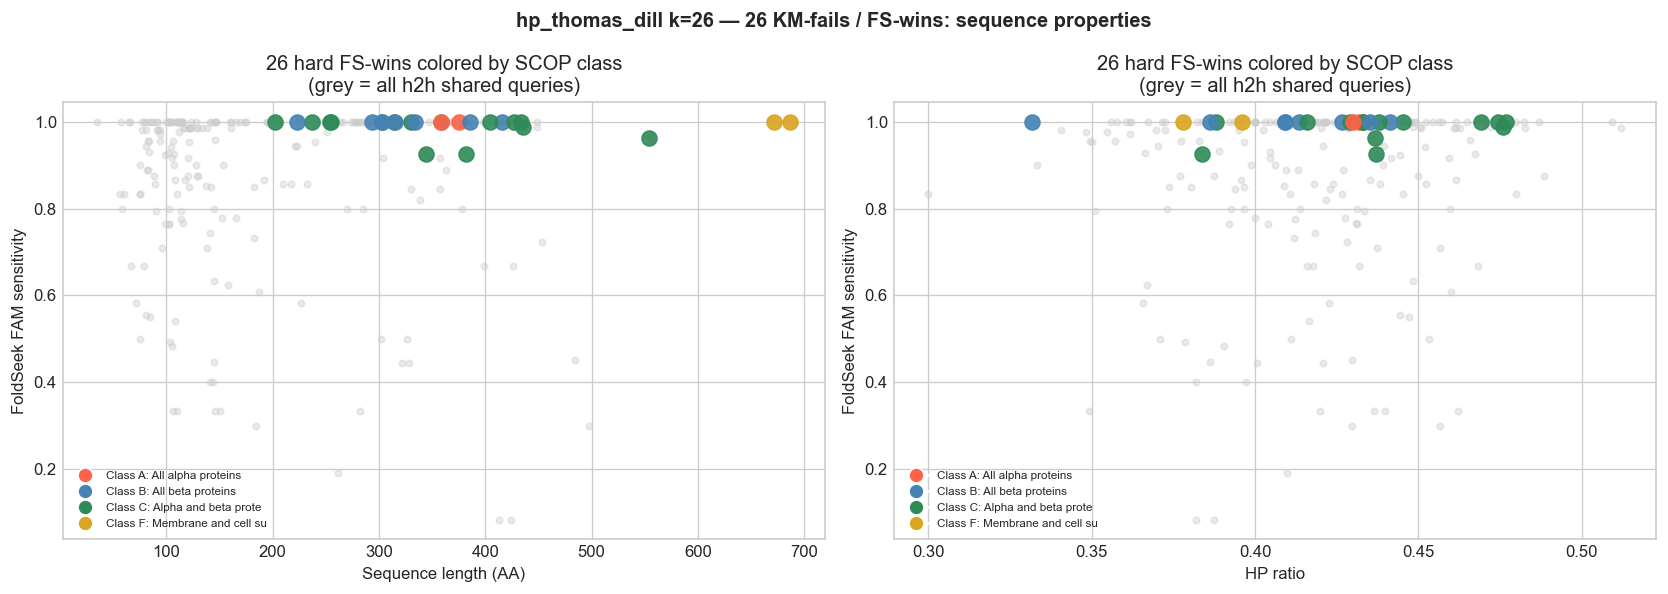

In [11]:
CLASS_COLORS = {
    'a': 'tomato', 'b': 'steelblue', 'c': 'seagreen',
    'd': 'mediumpurple', 'f': 'goldenrod', 'g': 'darkorange',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, (xvals_all, xvals_26, xlabel) in enumerate([
    (lens_shared, lens_26, 'Sequence length (AA)'),
    (hp_shared,   hp_26,   'HP ratio'),
]):
    ax = axes[ax_idx]
    # background
    ax.scatter(xvals_all, [fs_arr[i] for i in range(len(shared)) if shared[i] in seq_info],
               color='#ccc', alpha=0.4, s=15, zorder=1)
    # 26 fails colored by class
    q_with_seq = [q for q in fs_wins_26 if q in seq_info]
    for q in q_with_seq:
        cls   = fs_scop_d[q][0]
        color = CLASS_COLORS.get(cls, 'black')
        xv    = seq_info[q]['len'] if ax_idx == 0 else seq_info[q]['hp_ratio']
        ax.scatter(xv, fs_fam_d[q], color=color, s=80, zorder=3, alpha=0.9)
    from matplotlib.lines import Line2D
    legend_els = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                         markersize=9, label=f'Class {k.upper()}: {SCOPE_CLASS_DESCRIPTIONS.get(k,"")[:20]}')
                  for k, c in CLASS_COLORS.items() if any(fs_scop_d[q][0] == k for q in fs_wins_26)]
    ax.legend(handles=legend_els, fontsize=7)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('FoldSeek FAM sensitivity')
    ax.set_title(f'26 hard FS-wins colored by SCOP class\n(grey = all h2h shared queries)')

plt.suptitle(f'{BEST_LABEL} k={BEST_K} — 26 KM-fails / FS-wins: sequence properties',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_PREFIX}_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Interpretation

Summarize findings below after running the cells.

In [12]:
print('=== Summary of 26 KM-fails / FS-wins ===')
print(f'\nSCOP class breakdown:')
for c, n in sorted(fails26_cls_cnt.items(), key=lambda x: -x[1]):
    bg_pct = 100 * shared_cls_cnt.get(c, 0) / len(shared)
    fail_pct = 100 * n / len(fs_wins_26)
    desc = SCOPE_CLASS_DESCRIPTIONS.get(c, c)
    print(f'  {c.upper()} ({desc[:35]}): {n} fails ({fail_pct:.0f}%)  vs  background {bg_pct:.0f}%  '
          f'[enrichment: {fail_pct - bg_pct:+.0f} pp]')

print(f'\nSequence length: 26 median={np.median(lens_26):.0f} AA  |  all h2h median={np.median(lens_shared):.0f} AA')
print(f'HP ratio: 26 median={np.median(hp_26):.3f}  |  all h2h median={np.median(hp_shared):.3f}')

print(f'\nFamily size: 26 median={np.median(famcnt_26):.0f}  |  all h2h median={np.median(famcnt_shared):.0f}')
print(f'  (if fails have SMALL families: KmerSeek may genuinely lack k-mer evidence)')
print(f'  (if fails have LARGE families: HP representation is the bottleneck, not data sparsity)')

print()
print('Families/classes with multiple representatives in the 26 (= systematic pattern):')
for fam, n in sorted(fam_cnts.items(), key=lambda x: -x[1]):
    if n > 1:
        cls = fails_df.filter(pl.col('scop_family') == fam)['scop_class'][0]
        print(f'  {fam} (class {cls.upper()}): {n} members')

=== Summary of 26 KM-fails / FS-wins ===

SCOP class breakdown:
  C (Alpha and beta proteins (a/b) — alt): 14 fails (54%)  vs  background 44%  [enrichment: +10 pp]
  B (All beta proteins): 8 fails (31%)  vs  background 22%  [enrichment: +8 pp]
  A (All alpha proteins): 2 fails (8%)  vs  background 14%  [enrichment: -6 pp]
  F (Membrane and cell surface proteins): 2 fails (8%)  vs  background 1%  [enrichment: +7 pp]

Sequence length: 26 median=351 AA  |  all h2h median=147 AA
HP ratio: 26 median=0.431  |  all h2h median=0.422

Family size: 26 median=8  |  all h2h median=21
  (if fails have SMALL families: KmerSeek may genuinely lack k-mer evidence)
  (if fails have LARGE families: HP representation is the bottleneck, not data sparsity)

Families/classes with multiple representatives in the 26 (= systematic pattern):
  b.69.4.0 (class B): 4 members
  c.67.1.0 (class C): 4 members
  c.1.8.1 (class C): 3 members
  a.118.17.0 (class A): 2 members
  c.1.18.0 (class C): 2 members
  f.4.3.0 (c